# DUSt3R Hands-On SPCOM Tutorial
## Instructor : Dr. Lokender Tiwari

**DUSt3R** takes a pair (or set) of *unposed, uncalibrated* images and directly regresses, for every pixel, a **3D point in a common reference frame** — no SfM pipeline, no known camera parameters, no bundle adjustment needed up front. From this single pointmap prediction you can derive:

1. **Monocular & multi-view depth**
2. **Dense pixel correspondences** between views
3. **Camera poses & intrinsics** (via a lightweight global alignment)
4. **Full dense 3D reconstruction**

This notebook walks through the following end-to-end tasks :
1. Single-pair inference with visualization of intermediate outputs (per-view pointmaps, depth, confidence)
2. Deriving and visualizing dense correspondences from the 3D pointmaps
3. Multi-view global alignment → camera poses + focal lengths + consistent 3D point cloud
4. Interactive Plotly 3D viewer
5. Export to `.ply`

**Before running:** `Runtime → Change runtime type → T4 GPU`.


## Step 0.  Confirm we have a GPU

In [1]:
!nvidia-smi
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


Tue Jul 14 19:31:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 1. Clone DUSt3R (with submodules)

DUSt3R embeds CroCo (its pretraining backbone) as a git submodule, so `--recursive` is required.


In [2]:
%cd /content
!git clone --recursive https://github.com/naver/dust3r --quiet
%cd /content/dust3r
!git submodule update --init --recursive


/content
/content/dust3r


## Step 2. Install dependencies

Colab already ships a recent PyTorch + CUDA build,


In [3]:
%cd /content/dust3r
!pip install -q -r requirements.txt
# Extra libs used later in this notebook for visualization / export
!pip install -q plotly trimesh
print("Dependencies installed.")


/content/dust3r
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.3 MB/s eta 0:00:00
Dependencies installed.


## Step 3. (Optional) Compile the RoPE CUDA kernels [Can be skipped]

DUSt3R uses RoPE positional embeddings (inherited from CroCo v2). Compiling the custom CUDA kernel speeds up inference but is optional — the model runs fine (just a bit slower)


In [5]:
# %cd /content/dust3r/croco/models/curope/
# !python setup.py build_ext --inplace || echo "curope build failed/skipped - continuing with the slower pure-PyTorch RoPE implementation"
# %cd /content/dust3r


## Step 4. Download the pretrained DUSt3R checkpoint

We use the `DUSt3R_ViTLarge_BaseDecoder_512_dpt` checkpoint (ViT-Large encoder, DPT head, 512px). It's ~1.3GB.


In [6]:
import os
os.makedirs('/content/dust3r/checkpoints', exist_ok=True)
%cd /content/dust3r
!wget -q --show-progress -O checkpoints/DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth \
    https://download.europe.naverlabs.com/ComputerVision/DUSt3R/DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth
!ls -lh checkpoints/


/content/dust3r
checkpoints/DUSt3R_ 100%[===================>]   2.13G  22.0MB/s    in 96s     
total 2.2G
-rw-r--r-- 1 root root 2.2G Jun 24  2024 DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth


## Step 5. Load the model

In [7]:
import sys
sys.path.insert(0, '/content/dust3r')

import torch
from dust3r.model import AsymmetricCroCo3DStereo

import torch
_orig_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_torch_load


device = 'cuda' if torch.cuda.is_available() else 'cpu'
ckpt_path = '/content/dust3r/checkpoints/DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth'

model = AsymmetricCroCo3DStereo.from_pretrained(ckpt_path).to(device)
model.eval()
print(f"DUSt3R loaded on {device}")


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
... loading model from /content/dust3r/checkpoints/DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth
instantiating : AsymmetricCroCo3DStereo(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100', patch_embed_cls='PatchEmbedDust3R', img_size=(512, 512), head_type='dpt', output_mode='pts3d', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), landscape_only=False)
<All keys matched successfully>
DUSt3R loaded on cuda


## Step 6. Sample images

We'll start with the two-view "Chateau" pair bundled in the repo (`croco/assets`). Feel free to replace `img_paths` with your own uploaded photos (use the commented-out upload cell below).


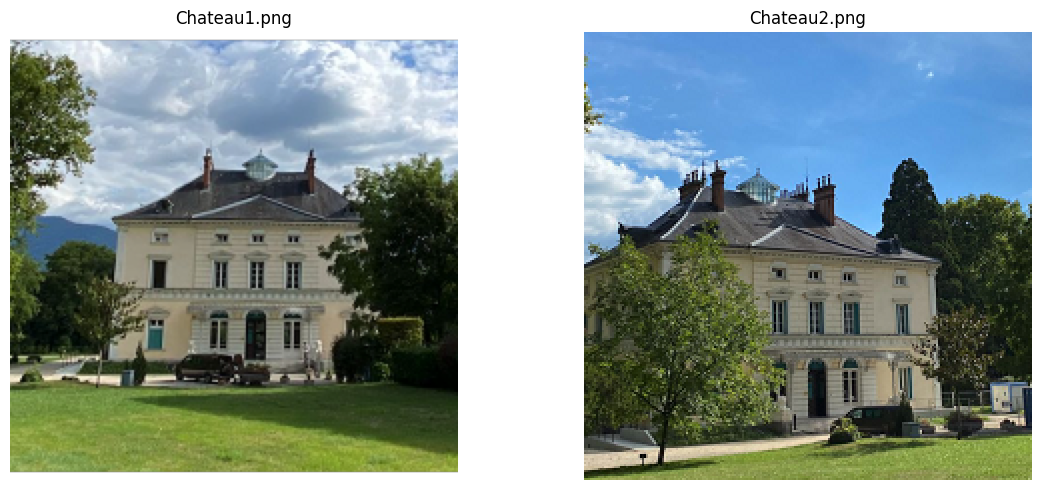

In [8]:
img_paths = [
    '/content/dust3r/croco/assets/Chateau1.png',
    '/content/dust3r/croco/assets/Chateau2.png',
]

import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, len(img_paths), figsize=(6 * len(img_paths), 5))
for ax, p in zip(axes, img_paths):
    ax.imshow(Image.open(p))
    ax.axis('off')
    ax.set_title(p.split('/')[-1])
plt.tight_layout()
plt.show()


In [ ]:
# Optional: uncomment to upload your own images instead
# from google.colab import files
# uploaded = files.upload()
# img_paths = list(uploaded.keys())


## Step 7. Run DUSt3R inference on the pair

This produces, for each view, a metric **3D point-map** (`pts3d`) and a per-pixel **confidence** map. Note the DUSt3R output-dict asymmetry:
- `pred1['pts3d']` — view1's pointmap, in view1's own coordinate frame.
- `pred2['pts3d_in_other_view']` — view2's pointmap, expressed in view1's frame (so the two are directly comparable/mergeable).


In [9]:
from dust3r.inference import inference
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs

images = load_images(img_paths, size=512)
pairs = make_pairs(images, scene_graph='complete', prefilter=None, symmetrize=True)
output = inference(pairs, model, device, batch_size=1, verbose=False)

view1, pred1 = output['view1'], output['pred1']
view2, pred2 = output['view2'], output['pred2']

print("pts3d (view1) shape             :", pred1['pts3d'].shape)
print("pts3d_in_other_view (view2)     :", pred2['pts3d_in_other_view'].shape)
print("confidence (view1) shape        :", pred1['conf'].shape)


>> Loading a list of 2 images
 - adding /content/dust3r/croco/assets/Chateau1.png with resolution 224x224 --> 512x384
 - adding /content/dust3r/croco/assets/Chateau2.png with resolution 224x224 --> 512x384
 (Found 2 images)


/content/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/content/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/content/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


pts3d (view1) shape             : torch.Size([2, 384, 512, 3])
pts3d_in_other_view (view2)     : torch.Size([2, 384, 512, 3])
confidence (view1) shape        : torch.Size([2, 384, 512])


## Step 8. Visualize intermediate outputs: depth & confidence

The Z-channel of each pointmap is effectively a depth map in the shared world frame; `conf` tells us how much DUSt3R trusts each pixel's estimate.


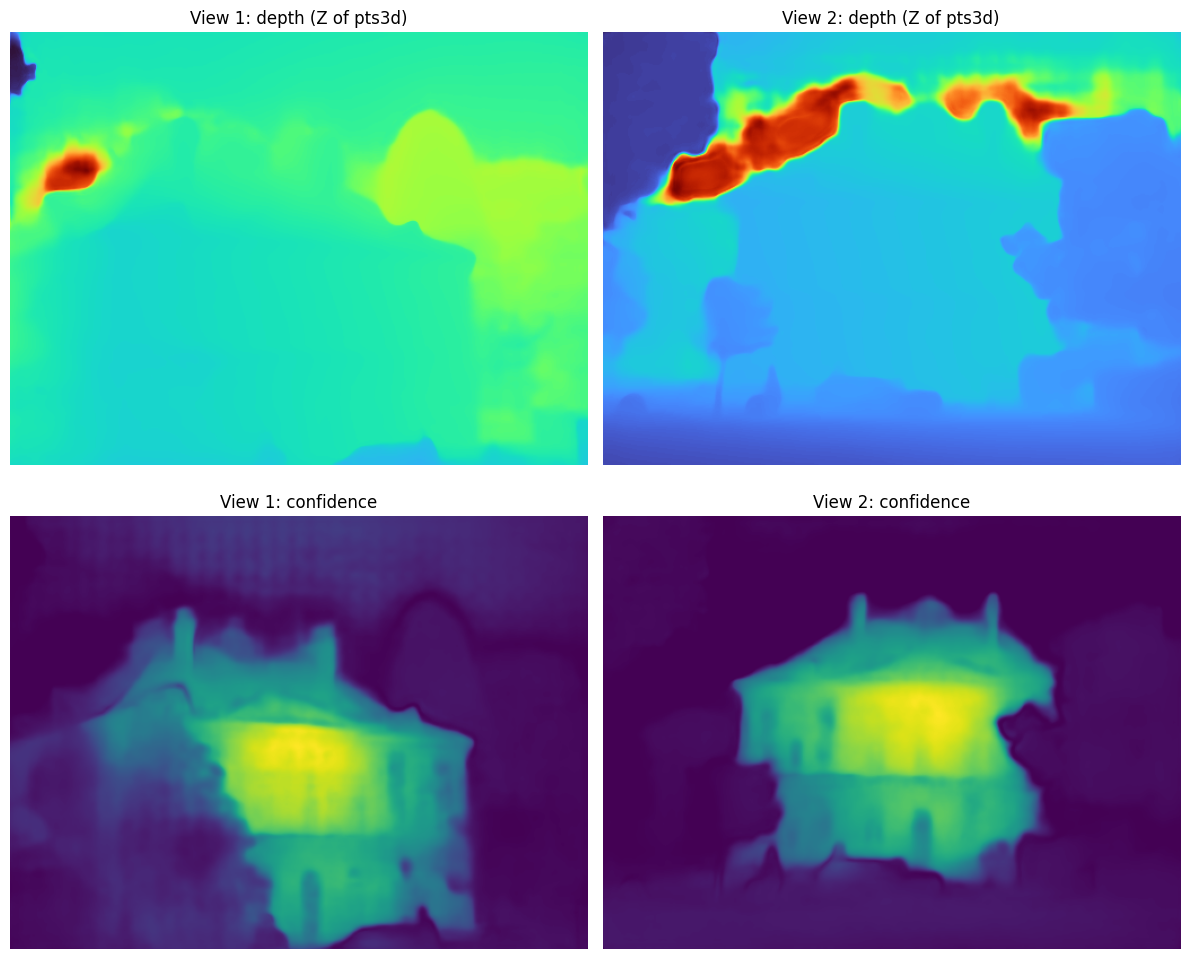

In [10]:
import numpy as np

def to_np(t):
    return t.detach().cpu().numpy()

# NOTE: because `pairs` contains 2 symmetrized entries (im1->im2 and im2->im1),
# output['pred1']/['pred2'] each hold 2 batch items. We look at the first (original) pair.
depths = {
    'View 1': to_np(pred1['pts3d'][0, ..., 2]),
    'View 2': to_np(pred2['pts3d_in_other_view'][0, ..., 2]),
}
confs = {
    'View 1': to_np(pred1['conf'][0]),
    'View 2': to_np(pred2['conf'][0]),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, name in enumerate(['View 1', 'View 2']):
    axes[0, i].imshow(depths[name], cmap='turbo')
    axes[0, i].set_title(f'{name}: depth (Z of pts3d)')
    axes[0, i].axis('off')
    axes[1, i].imshow(confs[name], cmap='viridis')
    axes[1, i].set_title(f'{name}: confidence')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()


## Step 9. Dense correspondences from the 3D pointmaps

DUSt3R has no dedicated matching head — but because both views' pointmaps live in the *same* coordinate frame, we can derive pixel correspondences ourselves: for a sample of confident pixels in view1, find the nearest 3D point (in world space) among view2's pixels. This is a direct, illustrative way to see the "geometry implies matching" idea behind the paper.


In [11]:
import numpy as np
from scipy.spatial import cKDTree

pts1 = to_np(pred1['pts3d'][0]).reshape(-1, 3)
pts2 = to_np(pred2['pts3d_in_other_view'][0]).reshape(-1, 3)
conf1 = to_np(pred1['conf'][0]).reshape(-1)
conf2 = to_np(pred2['conf'][0]).reshape(-1)

H, W = to_np(pred1['conf'][0]).shape

# Keep only reasonably confident pixels on both sides
thr1 = np.quantile(conf1, 0.5)
thr2 = np.quantile(conf2, 0.5)
valid2 = conf2 > thr2

tree = cKDTree(pts2[valid2])
valid2_idx = np.nonzero(valid2)[0]

# Sample confident pixels from view 1
candidates = np.nonzero(conf1 > thr1)[0]
rng = np.random.default_rng(0)
sample = rng.choice(candidates, size=min(80, len(candidates)), replace=False)

dists, nn = tree.query(pts1[sample])
matched2_flat = valid2_idx[nn]

# Keep only geometrically confident matches (small 3D distance)
good = dists < np.quantile(dists, 0.5)
sample, matched2_flat, dists = sample[good], matched2_flat[good], dists[good]

xy1 = np.stack([sample % W, sample // W], axis=1)
xy2 = np.stack([matched2_flat % W, matched2_flat // W], axis=1)

print(f"Derived {len(xy1)} illustrative correspondences (median 3D residual: {np.median(dists):.4f})")


Derived 40 illustrative correspondences (median 3D residual: 0.0007)


### Visualize the derived correspondences

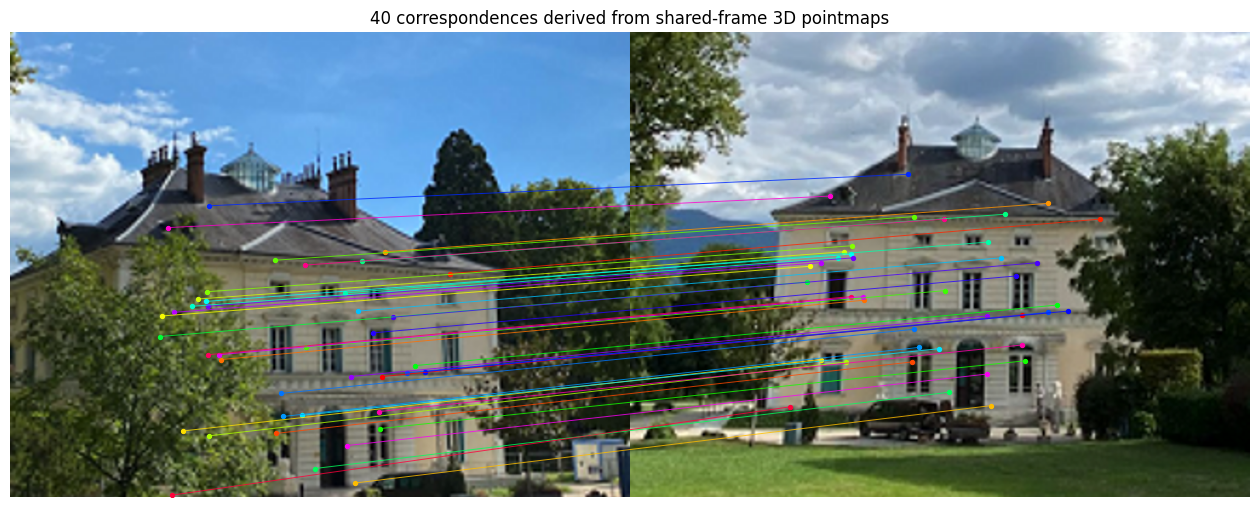

In [12]:
img0 = to_np(view1['img'][0]).transpose(1, 2, 0)
img1 = to_np(view2['img'][0]).transpose(1, 2, 0)
img0 = (img0 - img0.min()) / (img0.max() - img0.min())
img1 = (img1 - img1.min()) / (img1.max() - img1.min())

canvas = np.concatenate([img0, img1], axis=1)
Wc = img0.shape[1]

plt.figure(figsize=(16, 8))
plt.imshow(canvas)
cmap = plt.get_cmap('hsv')
for k in range(len(xy1)):
    x0, y0 = xy1[k]
    x1, y1 = xy2[k]
    color = cmap(k / max(len(xy1), 1))
    plt.plot([x0, x1 + Wc], [y0, y1], '-', color=color, linewidth=0.7, alpha=0.8)
    plt.scatter([x0, x1 + Wc], [y0, y1], color=color, s=8)
plt.axis('off')
plt.title(f'{len(xy1)} correspondences derived from shared-frame 3D pointmaps')
plt.show()


## Step 10. Multi-view 3D reconstruction & pose estimation (global alignment)

This is the headline downstream task: from a set of unposed images, jointly recover **camera poses, intrinsics, and a consistent dense point cloud** via DUSt3R's lightweight global alignment (gradient descent over a pairwise-consistency loss — no bundle-adjustment library required).

Add more image paths to `img_list` for a richer scene — even 3–6 photos of the same object/place from different angles works well.


In [13]:
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

img_list = img_paths  # reuse the 2-view Chateau pair; replace with more images if you have them

images = load_images(img_list, size=512)
pairs = make_pairs(images, scene_graph='complete', prefilter=None, symmetrize=True)
ga_output = inference(pairs, model, device, batch_size=1, verbose=False)

scene = global_aligner(ga_output, device=device, mode=GlobalAlignerMode.PointCloudOptimizer)
loss = scene.compute_global_alignment(init='mst', niter=300, schedule='cosine', lr=0.01)
print("Final alignment loss:", loss)


/content/dust3r/dust3r/cloud_opt/base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


>> Loading a list of 2 images
 - adding /content/dust3r/croco/assets/Chateau1.png with resolution 224x224 --> 512x384
 - adding /content/dust3r/croco/assets/Chateau2.png with resolution 224x224 --> 512x384
 (Found 2 images)
 init edge (1*,0*) score=np.float64(48.34419250488281)
 init loss = 0.0060300445184111595
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


  0%|          | 0/300 [00:00<?, ?it/s]/content/dust3r/dust3r/cloud_opt/base_opt.py:366: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(loss), lr
100%|██████████| 300/300 [00:14<00:00, 21.36it/s, lr=1.27413e-06 loss=0.00275607]

Final alignment loss: 0.0027560684829950333


### Extract the recovered poses, intrinsics and point cloud

In [14]:
imgs = scene.imgs
focals = scene.get_focals()
poses = scene.get_im_poses()
pts3d = scene.get_pts3d()
confidence_masks = scene.get_masks()

print("Recovered focal lengths:", [f.item() for f in focals])
for i, pose in enumerate(poses):
    print(f"Camera {i} pose (world-to-cam extrinsics):")
    print(to_np(pose))


Recovered focal lengths: [987.73779296875, 1168.50048828125]
Camera 0 pose (world-to-cam extrinsics):
[[ 0.8240484  -0.03919565 -0.5651619   0.16411497]
 [ 0.05788349  0.9982081   0.01516978  0.00674649]
 [ 0.5635546  -0.04521418  0.82484055  0.05164379]
 [ 0.          0.          0.          1.        ]]
Camera 1 pose (world-to-cam extrinsics):
[[ 9.9992597e-01 -1.0709192e-02  5.7939007e-03  0.0000000e+00]
 [ 1.0705541e-02  9.9994254e-01  6.6077022e-04  0.0000000e+00]
 [-5.8006435e-03 -5.9869443e-04  9.9998307e-01  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  1.0000000e+00]]


## Step 11. Interactive 3D visualization (point cloud + camera trajectory)

Rendered inline with Plotly so it works headlessly on Colab (no X server needed).


In [15]:
import plotly.graph_objects as go
import numpy as np

all_pts, all_colors = [], []
for img, pts, mask in zip(imgs, pts3d, confidence_masks):
    p = to_np(pts)[to_np(mask)]
    c = (np.array(img).reshape(-1, 3)[to_np(mask).reshape(-1)] * 255).astype(np.uint8)
    all_pts.append(p.reshape(-1, 3))
    all_colors.append(c)

all_pts = np.concatenate(all_pts, axis=0)
all_colors = np.concatenate(all_colors, axis=0)

# Subsample for a snappy interactive plot
n_max = 60000
if len(all_pts) > n_max:
    idx = np.random.default_rng(0).choice(len(all_pts), n_max, replace=False)
    all_pts, all_colors = all_pts[idx], all_colors[idx]

color_strs = [f'rgb({r},{g},{b})' for r, g, b in all_colors]

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=all_pts[:, 0], y=all_pts[:, 1], z=all_pts[:, 2],
    mode='markers', marker=dict(size=1.5, color=color_strs), name='point cloud'
))

# Camera centers + trajectory
cam_centers = np.stack([to_np(p)[:3, 3] for p in poses])
fig.add_trace(go.Scatter3d(
    x=cam_centers[:, 0], y=cam_centers[:, 1], z=cam_centers[:, 2],
    mode='markers+lines+text',
    marker=dict(size=6, color='red'),
    line=dict(color='red', width=3),
    text=[f'cam{i}' for i in range(len(cam_centers))],
    name='camera trajectory'
))

fig.update_layout(
    scene=dict(aspectmode='data'),
    margin=dict(l=0, r=0, b=0, t=30),
    title='DUSt3R reconstruction: dense point cloud + recovered camera poses'
)
fig.show()


## Step 12. Export the reconstruction (.ply)

Downloadable point cloud you can open in MeshLab / CloudCompare / Blender.


In [ ]:
import trimesh

cloud = trimesh.PointCloud(vertices=all_pts, colors=all_colors)
out_path = '/content/dust3r_reconstruction.ply'
cloud.export(out_path)
print(f"Saved point cloud to {out_path}")

from google.colab import files
files.download(out_path)
